# Task 1.5: Analysis of Resource Availabilities of the BPIC-17 Eventlog

### Imports and Setup

In [357]:
import pm4py as pm
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [358]:
log = pm.read_xes("../../data/BPI Challenge 2017.xes.gz")
df_raw = pm.convert_to_dataframe(log)

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

In [359]:
df_whole = df_raw.copy()

Data Cleaning

In [360]:
df_whole.rename(columns={
    'org:resource': 'Resource',
    'concept:name': 'Activity',
    'time:timestamp': 'Timestamp',
    'lifecycle:transition': 'State',
    'case:concept:name': 'Case'
}, inplace=True)
df_whole.drop(columns=['EventOrigin', 'EventID', 'case:LoanGoal', 'case:ApplicationType', 'case:RequestedAmount',
       'FirstWithdrawalAmount', 'NumberOfTerms', 'Accepted', 'MonthlyCost',
       'Selected', 'CreditScore', 'OfferedAmount', 'OfferID'], inplace=True)

df_whole['ResourceId'] = df_whole['Resource'].astype(str).str.lstrip('User_').astype(int)   # Used for sorting and quicker access
df_whole['Date'] = df_whole['Timestamp'].dt.date    # Needed for grouping
df_whole['Time'] = df_whole['Timestamp'].dt.time

In [361]:
# Use filtered dataframe from bpnm model for analysis
df_filtered = df_whole[~df_whole['Activity'].isin(['W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection', 'O_Sent (online only)'])]     # Activities not in bpmn model
df_filtered = df_filtered[df_filtered['State'].isin(['start', 'complete'])]

In [362]:
# Set df value for analysis
df = df_filtered
df = df.sort_values(['Resource', 'Timestamp'])

## Basic Approach
Daily Schedules based on median for 1-week interval

In [363]:
df.head()

,Action,Resource,Activity,State,Timestamp,Case,ResourceId,Date,Time
0,Created,User_1,A_Create Application,complete,2016-01-01 09:51:15.304000+00:00,Application_652823628,1,2016-01-01,09:51:15.304000
1,statechange,User_1,A_Submitted,complete,2016-01-01 09:51:15.352000+00:00,Application_652823628,1,2016-01-01,09:51:15.352000
5,statechange,User_1,A_Concept,complete,2016-01-01 09:52:36.413000+00:00,Application_652823628,1,2016-01-01,09:52:36.413000
40,Created,User_1,A_Create Application,complete,2016-01-01 10:16:11.500000+00:00,Application_1691306052,1,2016-01-01,10:16:11.500000
41,statechange,User_1,A_Submitted,complete,2016-01-01 10:16:11.549000+00:00,Application_1691306052,1,2016-01-01,10:16:11.549000


### Extract daily schedules using first and last timestamp

Take first start/complete timestamp and last complete timestamp

In [364]:
a_o_acts = (df.loc[df['Activity'].str.startswith(('A_', 'O_')), 'Activity'].unique().tolist())

# Define start-end conditions
valid_start_condition = ((df['State'] == 'start') 
                         | ((df['State'] == 'complete') 
                            & (df['Activity'].isin(a_o_acts))))   # A_/O_ activities only have state 'complete'
valid_end_condition = (df['State'] == 'complete')

# Extract valid start and end times
starts = (df[valid_start_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .min().rename('StartTime'))
ends = (df[valid_end_condition].groupby(['ResourceId', 'Resource', 'Date'])['Timestamp']
        .max().rename('EndTime'))

daily_shifts = pd.concat([starts, ends], axis=1, join='inner').reset_index()

Add relevant info needed for grouping later

In [365]:
daily_shifts['WorkedHours'] = (daily_shifts['EndTime'] - daily_shifts['StartTime']).dt.total_seconds() / 3600

# Add weekday information
daily_shifts['WeekdayName'] = pd.to_datetime(daily_shifts['Date']).dt.day_name()
daily_shifts['WeekdayId'] = pd.to_datetime(daily_shifts['Date']).dt.dayofweek

# Convert time objects to float to calculate median
daily_shifts['StartAsFloat'] = daily_shifts['StartTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)
daily_shifts['EndAsFloat'] = daily_shifts['EndTime'].apply(lambda x: x.hour + x.minute / 60 + x.second / 3600)

print(f"Extracted {len(daily_shifts)} valid daily shifts.")
daily_shifts.head()

Extracted 11578 valid daily shifts.


,ResourceId,Resource,Date,StartTime,EndTime,WorkedHours,WeekdayName,WeekdayId,StartAsFloat,EndAsFloat
0,1,User_1,2016-01-01,2016-01-01 09:51:15.304000+00:00,2016-01-01 21:58:53.572000+00:00,12.127297,Friday,4,9.854167,21.981389
1,1,User_1,2016-01-02,2016-01-02 01:08:49.567000+00:00,2016-01-02 22:21:24.689000+00:00,21.209756,Saturday,5,1.146944,22.356667
2,1,User_1,2016-01-03,2016-01-03 03:12:06.921000+00:00,2016-01-03 22:04:43.500000+00:00,18.876828,Sunday,6,3.201667,22.078611
3,1,User_1,2016-01-04,2016-01-04 00:27:52.920000+00:00,2016-01-04 22:28:04.261000+00:00,22.003150,Monday,0,0.464444,22.467778
4,1,User_1,2016-01-05,2016-01-05 00:13:37.421000+00:00,2016-01-05 23:12:17.820000+00:00,22.977889,Tuesday,1,0.226944,23.204722


Filter out short shifts

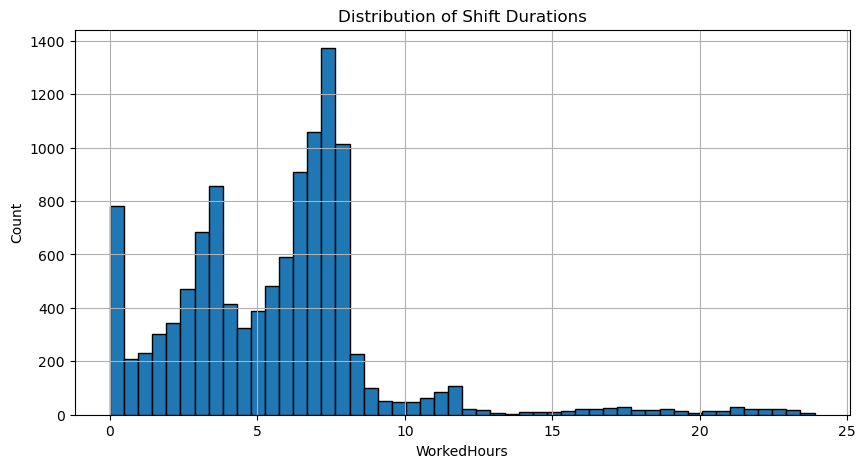

In [366]:
plt.figure(figsize=(10, 5))
daily_shifts['WorkedHours'].hist(bins=50, edgecolor='black')
plt.title('Distribution of Shift Durations')
plt.xlabel('WorkedHours')
plt.ylabel('Count')
plt.savefig("files/distribution_of_shift_durations.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [367]:
min_hours = 2.0
shifts_cleaned = daily_shifts[daily_shifts['WorkedHours'] >= min_hours].copy()

print(f"Original Days: {len(daily_shifts)}")
print(f"Cleaned Days:  {len(shifts_cleaned)}")
print(f"Dropped {len(daily_shifts) - len(shifts_cleaned)} short shifts.")

Original Days: 11578
Cleaned Days:  10002
Dropped 1576 short shifts.


In [368]:
shifts_cleaned.describe()

,ResourceId,WorkedHours,WeekdayId,StartAsFloat,EndAsFloat
count,10002.000000,10002.000000,10002.000000,10002.000000,10002.000000
mean,59.843731,6.442457,2.157768,8.945588,15.388045
std,39.906769,3.283124,1.575518,2.913570,2.910105
min,1.000000,2.001431,0.000000,0.009167,6.621111
25%,27.000000,4.008635,1.000000,7.235069,13.757569
50%,53.000000,6.492297,2.000000,8.167361,14.936250
75%,98.000000,7.534203,3.000000,10.034653,16.967014
max,144.000000,23.887987,6.000000,18.460278,23.996944


### Derive weekly schedule by taking the median for each week day

In [369]:
weekly_schedule = shifts_cleaned.groupby(['ResourceId', 'Resource', 'WeekdayId']).agg(
    MedianStart=('StartAsFloat', 'median'),
    MedianEnd=('EndAsFloat', 'median'),
    ShiftCount=('Date', 'count')
).reset_index()

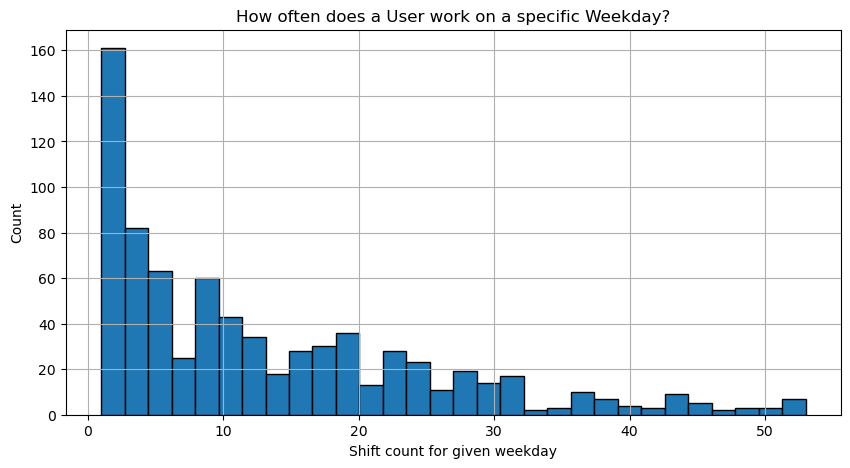

In [370]:
plt.figure(figsize=(10, 5))
weekly_schedule['ShiftCount'].hist(bins=30, edgecolor='black')
plt.title('How often does a User work on a specific Weekday?')
plt.xlabel('Shift count for given weekday')
plt.ylabel('Count')
plt.savefig("files/shift_consistency_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

- most people don't work consistent hours

Convert back to Time object and export as csv

In [371]:
def float_to_time(x):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return pd.to_datetime(f"{hours}:{minutes}", format="%H:%M").time()

weekly_schedule['StartTime'] = weekly_schedule['MedianStart'].apply(float_to_time)
weekly_schedule['EndTime'] = weekly_schedule['MedianEnd'].apply(float_to_time)

In [372]:
res_availvabilities = weekly_schedule[['Resource', 'WeekdayId', 'StartTime', 'EndTime']].copy()
res_availvabilities.rename(columns={'WeekdayId': 'DayId'}, inplace=True)
res_availvabilities.to_csv('availabilities_basic.csv', index=False)

## Deeper Analysis of resource availabilities for fixed intervals

#### WorkedHours

In [373]:
# Group daily durations by weekday
weekday_stats = daily_shifts.groupby(['Resource', 'ResourceId', 'WeekdayName', 'WeekdayId'])['WorkedHours'].agg(
    AverageHours='mean',
    MedianHours='median',
    StdDev='std',
    ShiftCount='count'
).reset_index()
weekday_stats['std/mean'] = weekday_stats['StdDev'] / weekday_stats['AverageHours']
weekday_stats = weekday_stats.sort_values(by=['ResourceId', 'WeekdayId'])

Global overview

In [374]:
global_weekday_stats = weekday_stats.groupby(['WeekdayId', 'WeekdayName'])['AverageHours'].agg(
    GlobalAverage='mean',
    GlobalMedian='median',
    GlobalStd='std',
    UserCount='count'
).reset_index()

global_weekday_stats = global_weekday_stats.sort_values('WeekdayId')
global_weekday_stats

,WeekdayId,WeekdayName,GlobalAverage,GlobalMedian,GlobalStd,UserCount
0,0,Monday,5.012140,5.237444,2.027863,139
1,1,Tuesday,5.096329,5.263664,2.120597,135
2,2,Wednesday,4.865275,5.022479,2.278437,141
3,3,Thursday,4.825884,4.823128,2.190126,137
4,4,Friday,4.551105,4.603604,2.043248,137
5,5,Saturday,4.755811,5.074261,2.005010,91
6,6,Sunday,4.073455,4.223083,3.223354,25


In [375]:
def get_metric_overview(metric):
    pivot_overview = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values=metric).fillna(0)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_overview = pivot_overview.reindex(columns=days_order).sort_index()
    return pivot_overview.style.background_gradient(cmap='YlGnBu', axis=None).format("{:.1f}")

def color_thresholds(val):
    if val < 0.3:
        color ='#90EE90'
    elif val < 0.5:
        color = '#FFFFE0'
    else:
        color = '#FF7F7F'
    return f'background-color: {color}'

Average

In [376]:
avg_hours_overview = get_metric_overview('AverageHours')
avg_hours_overview.to_html("files/avg_hours.html")
print("Created 'avg_hours.html'")

Created 'avg_hours.html'


- User_1 consistent high activity => most likely system
- work hours around 4-6 hours
- some work consistently on Saturdays

Median

In [377]:
median_hours_overview = get_metric_overview('MedianHours')
median_hours_overview.to_html("files/median_hours.html")
print("Created 'median_hours.html'")

Created 'median_hours.html'


Relative Standard Deviation

In [378]:
std_hours_overview = get_metric_overview('StdDev')
std_hours_overview.to_html("files/std_hours.html")
print("Created 'std_hours.html'")

Created 'std_hours.html'


In [379]:
# Get better overview over relative standard deviation
pivot_relstd = weekday_stats.pivot(index='ResourceId', columns='WeekdayName', values='std/mean').fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_relstd = pivot_relstd.reindex(columns=days_order).sort_index()
relstd_overview = pivot_relstd.style.map(color_thresholds).format("{:.1f}")
relstd_overview.to_html("files/relative_standard_deviation.html")
print("Created 'relative_standard_deviation.html'")

Created 'relative_standard_deviation.html'


#### Inspect resource shifts for single users

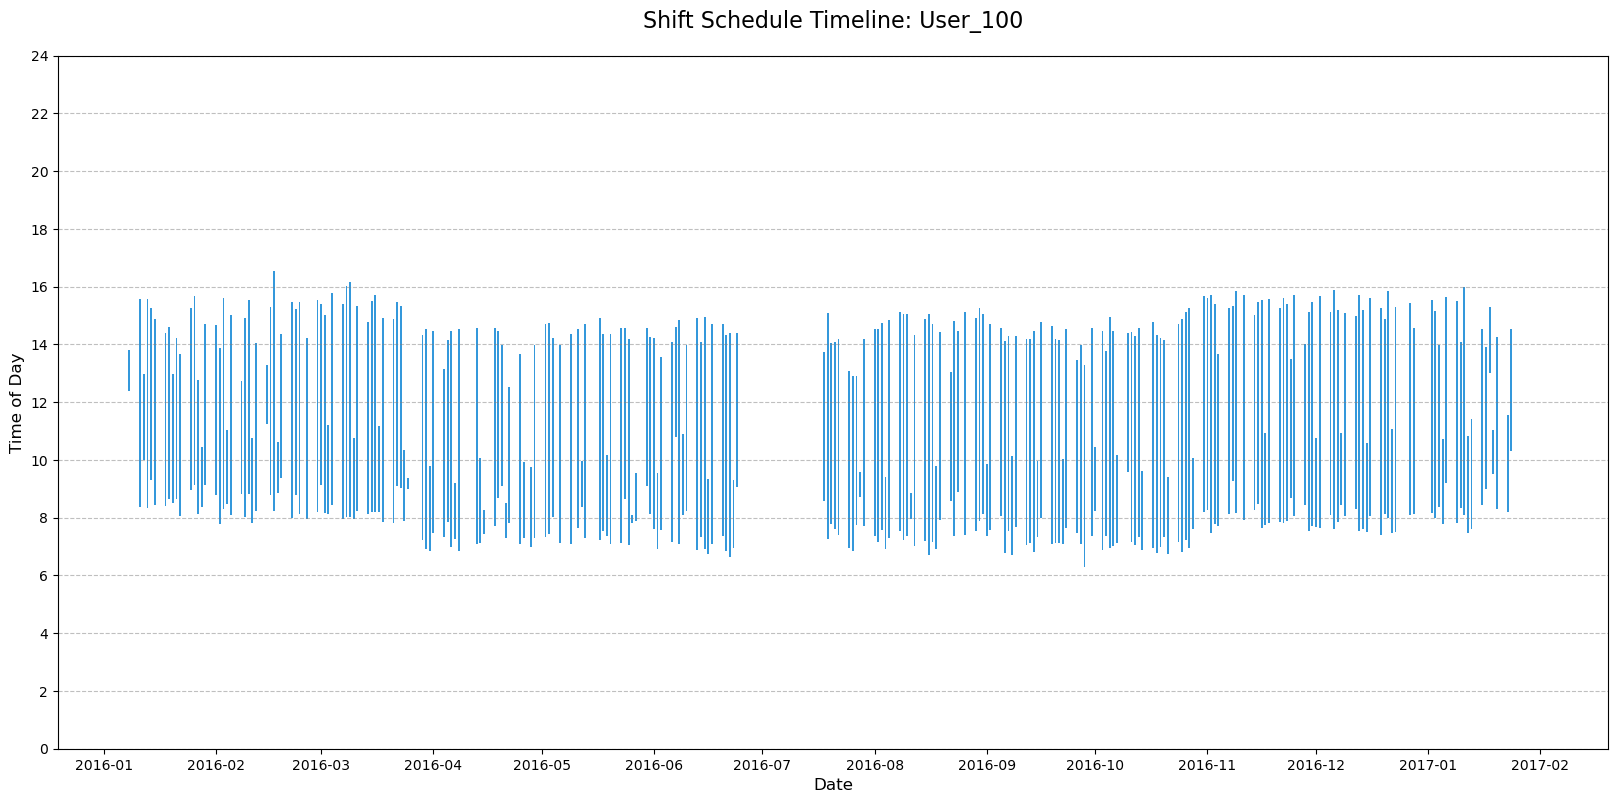

In [380]:
res_id = 'User_100'
tmp = daily_shifts[daily_shifts['Resource'] == res_id].copy()

fig, ax = plt.subplots(figsize=(20, 9))
ax.bar(
    mdates.date2num(tmp['Date']),
    tmp['WorkedHours'],
    bottom=tmp['StartTime'].apply(lambda x: x.hour + x.minute / 60),
    width=0.5,
    color='#3498db',
    edgecolor='none',
    align='center'
)
locator = mdates.MonthLocator(interval=1)
ax.xaxis.set_major_locator(locator)

formatter = mdates.DateFormatter('%Y-%m')
ax.xaxis.set_major_formatter(formatter)

ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_ylabel("Time of Day", fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5, color='gray')

ax.set_title(f"Shift Schedule Timeline: {res_id}", fontsize=16, pad=20)
ax.set_xlabel("Date", fontsize=12)
plt.savefig(f"files/shift_schedule_timeline_{res_id}.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Advanced Approach

#### Holidays

Find lower volume days based on daily shifts

In [381]:
daily_volume = daily_shifts.groupby(['Date', 'WeekdayId'])['WorkedHours'].sum().reset_index()

weekdays_only = daily_volume[daily_volume['WeekdayId'] < 5]
baseline_volume = weekdays_only['WorkedHours'].median()
print(f"Standard Daily Volume: {baseline_volume:.1f} hours")

threshold = 0.3
is_holiday = ((daily_volume['WeekdayId'] < 5) & 
        (daily_volume['WorkedHours'] < (baseline_volume * threshold)))
    
holidays = daily_volume[is_holiday].copy()
holidays['Ratio'] = holidays['WorkedHours'] / baseline_volume
holidays = holidays.sort_values('Date')
print(f"\nDetected {len(holidays)} Holidays:")
holidays

Standard Daily Volume: 224.6 hours

Detected 16 Holidays:


,Date,WeekdayId,WorkedHours,Ratio
0,2016-01-01,4,12.127297,0.054004
117,2016-04-27,2,42.222226,0.188021
125,2016-05-05,3,53.229695,0.237038
136,2016-05-16,0,56.043163,0.249567
360,2016-12-26,0,49.110984,0.218697
382,2017-01-17,1,63.046886,0.280756
384,2017-01-19,3,52.675935,0.234573
385,2017-01-20,4,62.544444,0.278518
388,2017-01-23,0,64.884578,0.288939
389,2017-01-24,1,38.352314,0.170788


from https://www.government.nl/topics/working-hours/question-and-answer/public-holidays-in-the-netherlands:
- New Year's: 01 January
- King's Day: 27 April
- Liberation Day: 5 May
- Ascension Day: different every year
- Christmas Day: 25 December
- Boxing Day: 26 December

In [382]:
holidays['Date'] = pd.to_datetime(holidays['Date'])
holidays_filtered = holidays[holidays['Date'].dt.year < 2017].copy()
holidays_filtered

,Date,WeekdayId,WorkedHours,Ratio
0,2016-01-01,4,12.127297,0.054004
117,2016-04-27,2,42.222226,0.188021
125,2016-05-05,3,53.229695,0.237038
136,2016-05-16,0,56.043163,0.249567
360,2016-12-26,0,49.110984,0.218697


In [383]:
daily_shifts['Date'] = pd.to_datetime(daily_shifts['Date'])
active_on_holiday = daily_shifts[
        (daily_shifts['Date'].isin(holidays_filtered['Date'].tolist())) & 
        (daily_shifts['WorkedHours'] > 0.01)
    ]
    
print("Users working on holidays:")
if active_on_holiday.empty:
    print("No one!")
else:
    workers_per_day = active_on_holiday.groupby('Date')['Resource'].unique()
    for date_val, workers in workers_per_day.items():
        worker_list = ", ".join(workers)
        print(f"   - {date_val}: {len(workers)} active ({worker_list})")

Users working on holidays:
   - 2016-01-01 00:00:00: 1 active (User_1)
   - 2016-04-27 00:00:00: 9 active (User_1, User_3, User_18, User_35, User_36, User_42, User_44, User_75, User_117)
   - 2016-05-05 00:00:00: 11 active (User_1, User_3, User_12, User_13, User_14, User_26, User_31, User_38, User_43, User_49, User_116)
   - 2016-05-16 00:00:00: 12 active (User_1, User_4, User_13, User_15, User_16, User_24, User_28, User_36, User_42, User_49, User_60, User_125)
   - 2016-12-26 00:00:00: 8 active (User_1, User_39, User_42, User_51, User_52, User_61, User_66, User_113)


#### Lunch Break

In [384]:
df_adv = df_filtered[df_filtered['Resource'] != 'User_1'].copy()  # User_1 is system with no lunch break

Plot timestamps with status 'start' or 'complete' for a specific user

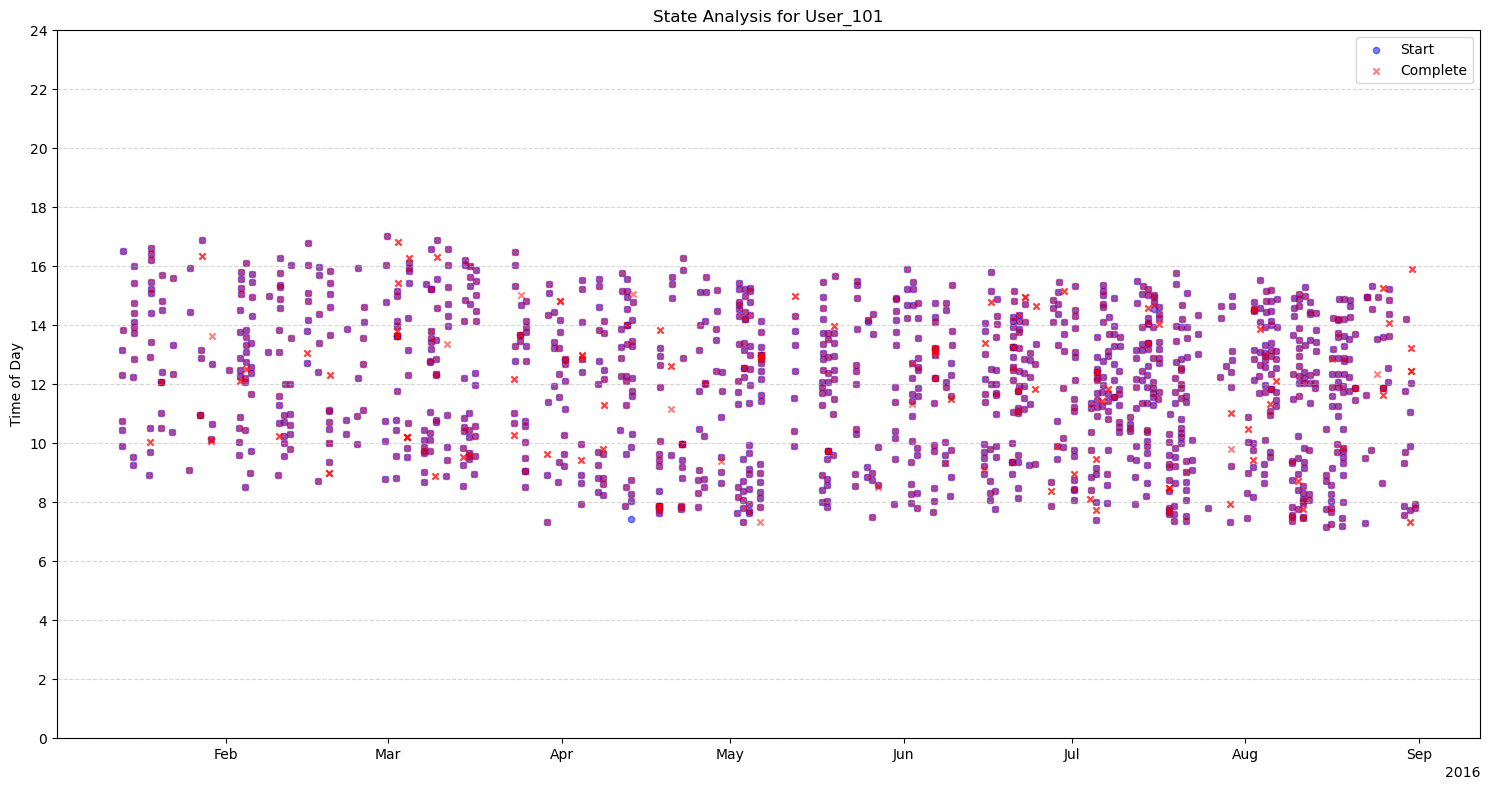

In [385]:
user_id = 'User_101'  # Change to inspect different users
user_df = df_adv[df_adv['Resource'] == user_id].copy()
user_df['TimeFloat'] = (
        user_df['Timestamp'].dt.hour + 
        user_df['Timestamp'].dt.minute / 60 + 
        user_df['Timestamp'].dt.second / 3600
    )
starts = user_df[user_df['State'] == 'start']
completes = user_df[user_df['State'] == 'complete']

fig, ax = plt.subplots(figsize=(15, 8))
ax.scatter(starts['Timestamp'], starts['TimeFloat'], color='blue', alpha=0.5, s=20, label='Start')
ax.scatter(completes['Timestamp'], completes['TimeFloat'], color='red', marker='x', alpha=0.5, s=20, label='Complete')
ax.set_ylim(0, 24)
ax.set_yticks(range(0, 25, 2))
ax.set_ylabel('Time of Day')

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.title(f'State Analysis for {user_id}')
plt.grid(True, which='both', axis='y', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f"files/break_time_analysis_{res_id}.pdf", format="pdf", bbox_inches="tight")
plt.show()

Extract longest period between complete/complete or complete/start timestamps to get breaks

In [386]:
df_adv = df_adv.sort_values(['Resource', 'Timestamp']).copy()

df_adv['NextTimestamp'] = df_adv.groupby('Resource')['Timestamp'].shift(-1)
df_adv['Gap'] = df_adv['NextTimestamp'] - df_adv['Timestamp']

valid_breaks = ((df_adv['State'] == 'complete') & 
        (df_adv['Timestamp'].dt.date == df_adv['NextTimestamp'].dt.date))   # gaps between State 'start' and 'complete' defined as 'working' not break'
    
potential_breaks = df_adv[valid_breaks].copy()

idx_longest = potential_breaks.groupby(['Resource', potential_breaks['Timestamp'].dt.date])['Gap'].idxmax()     # Longest break
breaks = potential_breaks.loc[idx_longest]
breaks = pd.DataFrame({
    'Resource': breaks['Resource'],
    'Date': breaks['Timestamp'].dt.date,
    'BreakStart': breaks['Timestamp'],
    'BreakEnd': breaks['NextTimestamp'],
    'Duration': breaks['Gap']
    })
breaks['DurationHours'] = breaks['Duration'].dt.total_seconds() / 3600
breaks

,Resource,Date,BreakStart,BreakEnd,Duration,DurationHours
3980,User_10,2016-01-04,2016-01-04 16:11:05.265000+00:00,2016-01-04 17:48:54.583000+00:00,0 days 01:37:49.318000,1.630366
2524,User_10,2016-01-05,2016-01-05 14:00:13.485000+00:00,2016-01-05 15:52:46.060000+00:00,0 days 01:52:32.575000,1.875715
11279,User_10,2016-01-06,2016-01-06 14:43:08.322000+00:00,2016-01-06 15:16:02.825000+00:00,0 days 00:32:54.503000,0.548473
21835,User_10,2016-01-08,2016-01-08 13:54:04.929000+00:00,2016-01-08 14:33:33.989000+00:00,0 days 00:39:29.060000,0.658072
22728,User_10,2016-01-09,2016-01-09 09:28:22.958000+00:00,2016-01-09 13:17:38.688000+00:00,0 days 03:49:15.730000,3.821036
...,...,...,...,...,...,...
1066833,User_99,2017-01-20,2017-01-20 12:25:23.951000+00:00,2017-01-20 12:25:23.957000+00:00,0 days 00:00:00.006000,0.000002
1066846,User_99,2017-01-23,2017-01-23 09:14:12.259000+00:00,2017-01-23 09:14:12.285000+00:00,0 days 00:00:00.026000,0.000007
1109520,User_99,2017-01-27,2017-01-27 11:38:17.102000+00:00,2017-01-27 14:57:39.243000+00:00,0 days 03:19:22.141000,3.322817
1192211,User_99,2017-01-30,2017-01-30 10:55:45.825000+00:00,2017-01-30 10:55:48.406000+00:00,0 days 00:00:02.581000,0.000717


Plot break durations

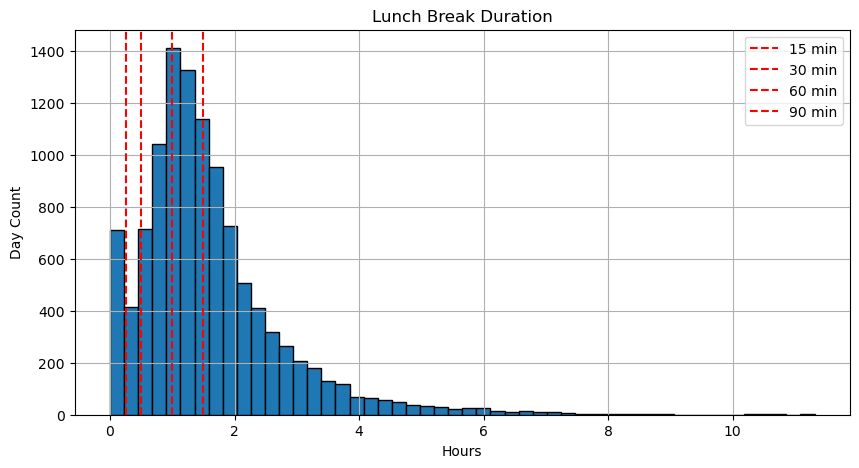

In [387]:
plt.figure(figsize=(10, 5))
breaks['DurationHours'].hist(bins=50, edgecolor='black')
plt.title('Lunch Break Duration')
plt.xlabel('Hours')
plt.ylabel('Day Count')
plt.axvline(x=0.25, color='r', linestyle='--', label='15 min')
plt.axvline(x=0.5, color='r', linestyle='--', label='30 min')
plt.axvline(x=1.0, color='r', linestyle='--', label='60 min')
plt.axvline(x=1.5, color='r', linestyle='--', label='90 min')
plt.legend()
plt.savefig(f"files/lunch_break_duration.pdf", format="pdf", bbox_inches="tight")
plt.show()

Filter out outliers

In [388]:
breaks.describe()

,Duration,DurationHours
count,11075,1.107500e+04
mean,0 days 01:34:57.314963611,1.582587e+00
std,0 days 01:09:15.746311286,1.154374e+00
min,0 days 00:00:00.002000,5.555556e-07
25%,0 days 00:53:14.593000,8.873869e-01
50%,0 days 01:20:36.003000,1.343334e+00
75%,0 days 01:59:02.590500,1.984053e+00
max,0 days 11:18:50.768000,1.131410e+01


In [389]:
min_hours = 15 / 60     # 15 min
max_hours = 3
breaks_cleaned = breaks[(breaks['DurationHours'] >= min_hours)
                        & (breaks['DurationHours'] <= max_hours)].copy()

print(f"Original Lunch Breaks: {len(breaks)}")
print(f"Cleaned Lunch Breaks:  {len(breaks_cleaned)}")
print(f"Dropped {len(breaks) - len(breaks_cleaned)} outliers.")

Original Lunch Breaks: 11075
Cleaned Lunch Breaks:  9243
Dropped 1832 outliers.


/var/folders/rz/mjmkgf7967x_k_v3fxtyf9th0000gn/T/ipykernel_97974/3801285547.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


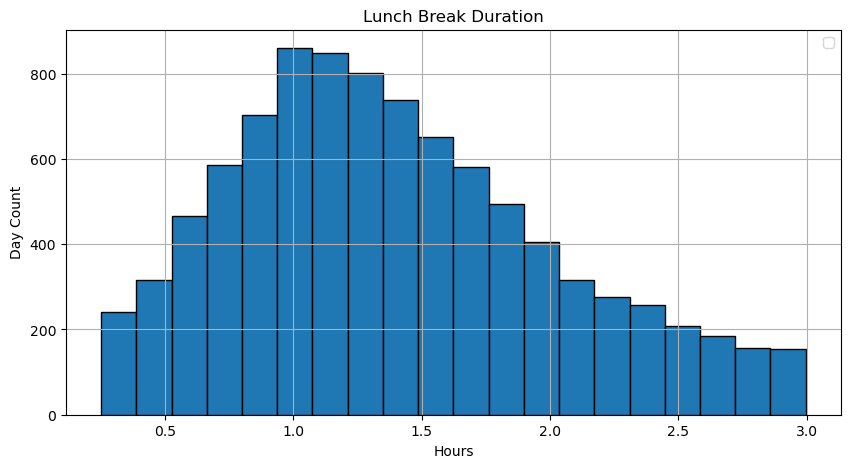

In [390]:
plt.figure(figsize=(10, 5))
breaks_cleaned['DurationHours'].hist(bins=20, edgecolor='black')
plt.title('Lunch Break Duration')
plt.xlabel('Hours')
plt.ylabel('Day Count')
plt.legend()
plt.savefig(f"files/lunch_break_duration_cleaned.pdf", format="pdf", bbox_inches="tight")
plt.show()

In [391]:
breaks_cleaned.describe()

,Duration,DurationHours
count,9243,9243.000000
mean,0 days 01:23:58.627384182,1.399619
std,0 days 00:37:32.468816343,0.625686
min,0 days 00:15:02.674000,0.250743
25%,0 days 00:56:16.090500,0.937803
50%,0 days 01:18:51.797000,1.314388
75%,0 days 01:48:03.193000,1.800887
max,0 days 02:59:46.571000,2.996270


#### Calculate median of all lunch break durations and start times (all data)

In [392]:
breaks_cleaned['BreakStartFloat'] = (
    breaks_cleaned['BreakStart'].dt.hour + 
    breaks_cleaned['BreakStart'].dt.minute / 60
)

breaks_cleaned_dof = breaks_cleaned.copy()
breaks_cleaned_dof['DayId'] = breaks_cleaned_dof['BreakStart'].dt.dayofweek
breaks_cleaned

,Resource,Date,BreakStart,BreakEnd,Duration,DurationHours,BreakStartFloat
3980,User_10,2016-01-04,2016-01-04 16:11:05.265000+00:00,2016-01-04 17:48:54.583000+00:00,0 days 01:37:49.318000,1.630366,16.183333
2524,User_10,2016-01-05,2016-01-05 14:00:13.485000+00:00,2016-01-05 15:52:46.060000+00:00,0 days 01:52:32.575000,1.875715,14.000000
11279,User_10,2016-01-06,2016-01-06 14:43:08.322000+00:00,2016-01-06 15:16:02.825000+00:00,0 days 00:32:54.503000,0.548473,14.716667
21835,User_10,2016-01-08,2016-01-08 13:54:04.929000+00:00,2016-01-08 14:33:33.989000+00:00,0 days 00:39:29.060000,0.658072,13.900000
11604,User_10,2016-01-11,2016-01-11 16:29:30.578000+00:00,2016-01-11 17:23:52.415000+00:00,0 days 00:54:21.837000,0.906066,16.483333
...,...,...,...,...,...,...,...
1187259,User_99,2017-01-09,2017-01-09 12:51:34.733000+00:00,2017-01-09 15:47:05.136000+00:00,0 days 02:55:30.403000,2.925112,12.850000
1200226,User_99,2017-01-11,2017-01-11 09:57:53.066000+00:00,2017-01-11 11:36:51.566000+00:00,0 days 01:38:58.500000,1.649583,9.950000
1182733,User_99,2017-01-17,2017-01-17 09:59:08.212000+00:00,2017-01-17 10:19:21.803000+00:00,0 days 00:20:13.591000,0.337109,9.983333
1195636,User_99,2017-01-18,2017-01-18 09:42:58.937000+00:00,2017-01-18 11:38:46.457000+00:00,0 days 01:55:47.520000,1.929867,9.700000


In [393]:
# Total average over all days
breaks_median = breaks_cleaned.groupby('Resource').agg(
    DurationMedian=('DurationHours', 'median'),
    BreakStartMedian=('BreakStartFloat', 'median')
).reset_index()
breaks_median['BreakStart'] = breaks_median['BreakStartMedian'].apply(float_to_time)
breaks_median['DurationMin'] = (breaks_median['DurationMedian'] * 60).round(0).astype(int)     # Convert to minutes
breaks_median

,Resource,DurationMedian,BreakStartMedian,BreakStart,DurationMin
0,User_10,1.222065,12.308333,12:18:00,73
1,User_100,1.194789,10.041667,10:02:00,72
2,User_101,1.586668,10.700000,10:41:00,95
3,User_102,1.436784,10.266667,10:16:00,86
4,User_103,0.432514,4.383333,04:23:00,26
...,...,...,...,...,...
136,User_95,1.445376,9.850000,09:50:00,87
137,User_96,1.003902,16.350000,16:21:00,60
138,User_97,0.696563,12.691667,12:41:00,42
139,User_98,0.709224,14.000000,14:00:00,43


In [394]:
breaks_median.describe()

,DurationMedian,BreakStartMedian,DurationMin
count,141.000000,141.000000,141.000000
mean,1.270197,11.783629,76.226950
std,0.300494,1.712958,18.033845
min,0.432514,4.383333,26.000000
25%,1.112264,10.700000,67.000000
50%,1.277718,11.450000,77.000000
75%,1.446507,12.641667,87.000000
max,2.449339,16.950000,147.000000


Plot start times

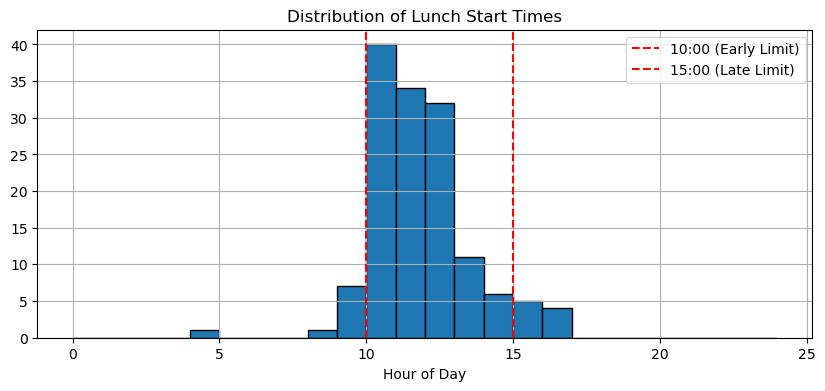

In [395]:
plt.figure(figsize=(10, 4))
breaks_median['BreakStartMedian'].hist(bins=24, range=(0, 24), edgecolor='black')
plt.title('Distribution of Lunch Start Times')
plt.xlabel('Hour of Day')
plt.axvline(x=10, color='red', linestyle='--', label='10:00 (Early Limit)')
plt.axvline(x=15, color='red', linestyle='--', label='15:00 (Late Limit)')
plt.legend()
plt.savefig(f"files/distributions_lunch_start_times.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### Median start times and durations grouped by weekdays

In [396]:
# Get median for weekdays
breaks_median_dof = breaks_cleaned_dof.groupby(['Resource', 'DayId']).agg(
    DurationMedian=('DurationHours', 'median'),
    BreakStartMedian=('BreakStartFloat', 'median')
).reset_index()
breaks_median_dof['BreakStart'] = breaks_median_dof['BreakStartMedian'].apply(float_to_time)
breaks_median_dof['DurationMin'] = (breaks_median_dof['DurationMedian'] * 60).round(0).astype(int)     # Convert to minutes
breaks_median_dof

,Resource,DayId,DurationMedian,BreakStartMedian,BreakStart,DurationMin
0,User_10,0,1.459993,16.316667,16:18:00,88
1,User_10,1,1.233884,13.725000,13:43:00,74
2,User_10,2,1.259660,11.533333,11:31:00,76
3,User_10,3,1.104185,11.083333,11:05:00,66
4,User_10,4,1.135168,10.866667,10:52:00,68
...,...,...,...,...,...,...
753,User_99,1,1.561296,9.800000,09:48:00,94
754,User_99,2,1.627346,10.141667,10:08:00,98
755,User_99,3,1.096850,10.366667,10:22:00,66
756,User_99,4,1.409326,10.041667,10:02:00,85


Save results to csv

In [397]:
res_lunch_break = breaks_median_dof[[
        'Resource', 
        'BreakStart',
        'DurationMin',
        'DayId'
    ]]
res_lunch_break

,Resource,BreakStart,DurationMin,DayId
0,User_10,16:18:00,88,0
1,User_10,13:43:00,74,1
2,User_10,11:31:00,76,2
3,User_10,11:05:00,66,3
4,User_10,10:52:00,68,4
...,...,...,...,...
753,User_99,09:48:00,94,1
754,User_99,10:08:00,98,2
755,User_99,10:22:00,66,3
756,User_99,10:02:00,85,4


In [398]:
res_availvabilities_adv = pd.merge(res_availvabilities, res_lunch_break, how='left')
res_availvabilities_adv['DurationMin'] = res_availvabilities_adv['DurationMin'].fillna(0)
res_availvabilities_adv['BreakStart'] = res_availvabilities_adv['BreakStart'].fillna("00:00:00")
res_availvabilities_adv

,Resource,DayId,StartTime,EndTime,BreakStart,DurationMin
0,User_1,0,04:17:00,22:55:00,00:00:00,0.0
1,User_1,1,02:25:00,22:56:00,00:00:00,0.0
2,User_1,2,02:56:00,22:52:00,00:00:00,0.0
3,User_1,3,03:59:00,22:47:00,00:00:00,0.0
4,User_1,4,04:17:00,22:48:00,00:00:00,0.0
...,...,...,...,...,...,...
758,User_144,0,06:19:00,10:35:00,00:00:00,0.0
759,User_144,1,07:57:00,12:40:00,10:28:00,50.0
760,User_144,2,08:34:00,13:33:00,09:39:00,103.0
761,User_144,3,09:07:00,14:41:00,13:09:00,91.0


### Evaluation of start, break and endtimes

In [429]:
def to_td(col):
    return pd.to_timedelta(col)

has_break = res_availvabilities_adv['DurationMin'] > 0
break_too_early = (to_td(res_availvabilities_adv['BreakStart'].astype(str)) < to_td(res_availvabilities_adv['StartTime'].astype(str))) & has_break
break_too_late = ((to_td(res_availvabilities_adv['BreakStart'].astype(str)) + pd.to_timedelta(res_availvabilities_adv['DurationMin'], unit='m')) > to_td(res_availvabilities_adv['EndTime'].astype(str))) & has_break

print(f"Total Shifts: {len(df)}")
print(f"Errors Found: {break_too_early.sum()} starts too early, {break_too_late.sum()} ends too late.")
print("\n--- Rows with Break Issues ---")
res_availvabilities_adv[(break_too_early | break_too_late)][['Resource', 'DayId', 'StartTime', 'EndTime', 'BreakStart', 'DurationMin']]

Total Shifts: 600790
Errors Found: 0 starts too early, 0 ends too late.

--- Rows with Break Issues ---


,Resource,DayId,StartTime,EndTime,BreakStart,DurationMin


In [428]:
# Set early breaks to 0
res_availvabilities_adv.loc[break_too_early, 'DurationMin'] = 0
res_availvabilities_adv.loc[break_too_early, 'BreakStart'] = "00:00:00"

# Set late breaks to end of shift
res_availvabilities_adv.loc[break_too_late, 'DurationMin'] = 0
remaining_time = to_td(res_availvabilities_adv['EndTime'].astype(str)) - to_td(res_availvabilities_adv['BreakStart'].astype(str))
remaining_minutes = remaining_time.dt.total_seconds() / 60
res_availvabilities_adv.loc[break_too_late, 'DurationMin'] = remaining_minutes[break_too_late].clip(lower=0).astype(int)


In [430]:
res_availvabilities_adv.to_csv('availabilities_advanced.csv', index=False)